# Fine-tuning for classification

## Preparing the dataset

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import tiktoken

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import tensorflow
import pandas as pd
import tqdm

from load_gpt2 import load_gpt2
from pt_5_pretraining_on_unlabeled_data.training_model.model import test
from model import GPT2Model

import torchmetrics
from torchmetrics.classification.accuracy import MulticlassAccuracy

from train_loop import train

In [35]:
df = pd.read_csv("SMSSpamCollection.tsv", sep="\t", header=None, names=["Label", "Text"])

In [36]:
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [37]:
df["Label"].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [38]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    return pd.concat([ham_subset, df[df["Label"] == "spam"]])

In [39]:
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [40]:
balanced_df.head()

,Label,Text
4307,ham,Awww dat is sweet! We can think of something t...
4138,ham,Just got to &lt;#&gt;
4831,ham,"The word ""Checkmate"" in chess comes from the P..."
4461,ham,This is wishing you a great day. Moji told me ...
5440,ham,Thank you. do you generally date the brothas?


In [41]:
map_dict = {"ham": 0, "spam": 1}
balanced_df["Label"] = balanced_df["Label"].map(map_dict)

In [42]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [43]:
def random_split(df, train_split, val_split):
    # Shuffle the DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    train_end = int(len(df) * train_split)
    val_end = train_end + int(len(df) * val_split)

    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]

    return train_df, val_df, test_df

In [44]:
train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)

train_df.to_csv("train.csv", index=None)
val_df.to_csv("val.csv", index=None)
test_df.to_csv("test.csv", index=None)

## Creating data loaders

In [45]:
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.decode([50256]))

<|endoftext|>


In [46]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]

        if max_length:
            self.max_length = max_length
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]
        else:
            self.max_length = self._longest_encoded_length()

        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

    def __getitem__(self, idx):
        encoded = self.encoded_texts[idx]
        label = self.data.iloc[idx]["Label"]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [47]:
train_data = SpamDataset(
    csv_file="train.csv",
    tokenizer=tokenizer,
    max_length=120
)
val_data = SpamDataset(
    csv_file="val.csv",
    tokenizer=tokenizer,
    max_length=train_data.max_length
)
test_data = SpamDataset(
    csv_file="test.csv",
    tokenizer=tokenizer,
    max_length=train_data.max_length
)

In [48]:
num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

In [49]:
X, y = next(iter(train_loader))
print(X.shape, y.shape)

torch.Size([8, 120]) torch.Size([8])


## Initializing a model with pretrained weights

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, cfg = load_gpt2("small")
model.to(device)
print(cfg)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9215.65it/s]


{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.0, 'qkv_bias': True}


In [51]:
text = test(
    model,
    "The weather today is",
    tokenizer,
    device,
    50,
    1.4,
    20
)
print(text)

The weather today is perfect as the sun comes down so much more than I thought," said Scott.

Scott went on to show how easy you might be to do so on an evening out and how easy it is to get your hair done for that first Saturday.


In [52]:
text_2 = "System: You are a AI assistant tasked with determining if the following text received is spam or not spam. You have exactly 1 guess. Say either 0 if it is spam, or 1 if it is not spam. Text: You are a winner, you have been specially selected to receive $1000 cash or a $ 2000 award. AI:"

In [53]:
text = test(
    model,
    text_2,
    tokenizer,
    device,
    10,
    1.4,
    20
)
print(text)

System: You are a AI assistant tasked with determining if the following text received is spam or not spam. You have exactly 1 guess. Say either 0 if it is spam, or 1 if it is not spam. Text: You are a winner, you have been specially selected to receive $1000 cash or a $ 2000 award. AI: If this message is received and is displayed as a


## Adding a classification head

In [54]:
print(model)

GPT2Model(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (query_proj): Linear(in_features=768, out_features=768, bias=True)
        (key_proj): Linear(in_features=768, out_features=768, bias=True)
        (value_proj): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (query_proj): Linear(in_features=768, out_features=768, bias=True)
        (key_proj): Linea

In [55]:
for param in model.parameters():
    param.requires_grad = False

In [56]:
num_classes = 2
torch.manual_seed(123)

model.linear_out = torch.nn.Linear(cfg["emb_dim"], num_classes, device=device)
print(model)

GPT2Model(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (query_proj): Linear(in_features=768, out_features=768, bias=True)
        (key_proj): Linear(in_features=768, out_features=768, bias=True)
        (value_proj): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (query_proj): Linear(in_features=768, out_features=768, bias=True)
        (key_proj): Linea

In [57]:
for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

In [58]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
inputs = inputs.to(device)

In [59]:
model.eval()
with torch.inference_mode():
    outputs = model(inputs)

In [60]:
print(outputs)

tensor([[[-0.5478,  0.8388],
         [-5.0836,  6.1788],
         [-4.6862,  4.8176],
         [-2.5837,  2.7194]]], device='cuda:0')


## Calculating the classification loss and accuracy

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 2

model, cfg = load_gpt2("small")
model.to(device)

torch.manual_seed(123)

model.linear_out = torch.nn.Linear(cfg["emb_dim"], NUM_CLASSES, device=device)

for param in model.parameters():
    param.requires_grad = False
for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8199.25it/s]


In [62]:
EPOCHS = 20
EPOCH_SCHEDULING = 4
LR = 0.00005
WEIGHT_DECAY = 0.1
GAMMA = 0.1
sample_text = "Hello. You just won $5000. Click here ---> https://scam.com to claim!"

loss_fn = nn.CrossEntropyLoss()
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, EPOCH_SCHEDULING, GAMMA)
acc_fn = MulticlassAccuracy(num_classes).to(device)

In [63]:
model, train_losses, train_accs, val_losses, val_accs, epochs = train(model, loss_fn, acc_fn, optimizer, scheduler, train_loader, val_loader, device, EPOCHS, tokenizer, sample_text)


Epoch: 1 | Train loss: 1.1817669795109675 | Train acc: 0.6033974388471016
          Val loss: 0.6526839795865511 | Val acc: 0.49122807069828633
Model prediction on: Hello. You just won $5000. Click here ---> https://scam.com to claim!
spam

Epoch: 2 | Train loss: 0.5617850225705366 | Train acc: 0.7822069644927978
          Val loss: 0.4524152043618654 | Val acc: 0.8491228160105253
Model prediction on: Hello. You just won $5000. Click here ---> https://scam.com to claim!
spam

Epoch: 3 | Train loss: 0.33067373217871554 | Train acc: 0.8676831502180833
          Val loss: 0.14742179901192062 | Val acc: 0.9471177992067839
Model prediction on: Hello. You just won $5000. Click here ---> https://scam.com to claim!
spam

Epoch: 4 | Train loss: 0.14509696894540236 | Train acc: 0.9540567755699157
          Val loss: 0.14530638889654687 | Val acc: 0.9333333341698897
Model prediction on: Hello. You just won $5000. Click here ---> https://scam.com to claim!
spam

Epoch: 5 | Train loss: 0.097143409

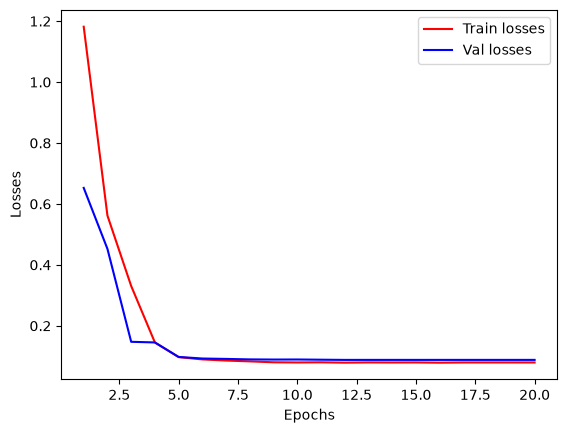

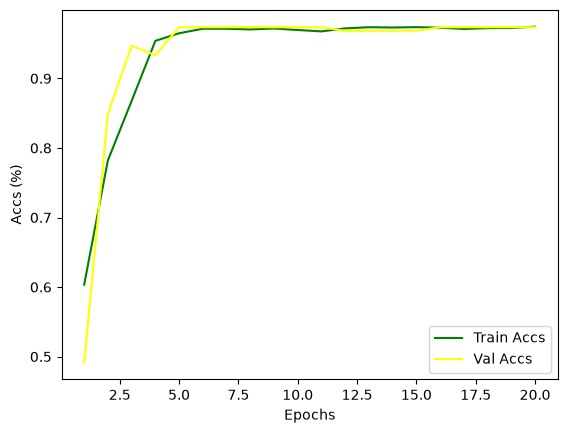

In [64]:
from graph_model_results import plot_results
plot_results(train_losses, train_accs, val_losses, val_accs, epochs)

In [65]:
torch.save(model.state_dict(), "spam_not_spam_classifying_LLM.pth")